# Time Series with Prophet Model - Air Quality

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [39]:
df = pd.read_csv("data/air-quality-data-combined.csv")
df.head()

,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5,pm10,site_id,device_name
0,"Athi, Nairobi",2025-01-01 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.706405,69.324027,16.30,17.58,664cac08e7b4f100136b72ef,airqo_g5300
1,"Athi, Nairobi",2025-01-02 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.730201,67.361020,11.96,12.67,664cac08e7b4f100136b72ef,airqo_g5300
2,"Athi, Nairobi",2025-01-03 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.036989,65.819461,14.27,15.27,664cac08e7b4f100136b72ef,airqo_g5300
3,"Athi, Nairobi",2025-01-04 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.471478,66.173176,8.89,9.43,664cac08e7b4f100136b72ef,airqo_g5300
4,"Athi, Nairobi",2025-01-05 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.362268,69.583073,11.62,12.33,664cac08e7b4f100136b72ef,airqo_g5300


**The data:** daily air quality readings from the AirQo network across 74 sites in Nairobi for 2025. We'll model PM2.5 (the fine-particle pollutant) at a single site.

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16374 entries, 0 to 16373
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_name    16374 non-null  str    
 1   datetime     16374 non-null  str    
 2   frequency    16374 non-null  str    
 3   network      16374 non-null  str    
 4   latitude     15801 non-null  float64
 5   longitude    15801 non-null  float64
 6   temperature  15801 non-null  float64
 7   humidity     15741 non-null  float64
 8   pm2_5        15801 non-null  float64
 9   pm10         15800 non-null  float64
 10  site_id      16374 non-null  str    
 11  device_name  16374 non-null  str    
dtypes: float64(6), str(6)
memory usage: 2.8 MB


## Data Cleaning

In [41]:
# 1) Missing values - count and share per column
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'missing': missing, 'percent': missing_pct})

,missing,percent
site_name,0,0.00
datetime,0,0.00
frequency,0,0.00
network,0,0.00
latitude,573,3.50
longitude,573,3.50
temperature,573,3.50
humidity,633,3.87
pm2_5,573,3.50
pm10,574,3.51


In [42]:
# missing PM2.5 is not random - it clusters in a few sites with long offline stretches
miss = df[df['pm2_5'].isnull()]
print(f"Rows with missing PM2.5: {len(miss)} ({len(miss) / len(df) * 100:.1f}%) across {miss['site_name'].nunique()} sites")
miss.groupby('site_name').size().sort_values(ascending=False).head(5)

Rows with missing PM2.5: 573 (3.5%) across 69 sites


site_name
Parklands, Nairobi    103
Juja Road              61
Kariokor               44
UN Avenue Gigiri       28
Dandora Phase II       22
dtype: int64

In [43]:
# 2) Duplicates - exact copies and repeated (site, date) readings
print("Exact duplicate rows:         ", df.duplicated().sum())
print("Duplicate (site, date) pairs:", df.duplicated(subset=['site_name', 'datetime']).sum())

Exact duplicate rows:          0
Duplicate (site, date) pairs: 0


In [44]:
# 3) Zero sensor values - physically impossible readings that point to sensor faults
for col in ['temperature', 'humidity', 'pm2_5', 'pm10']:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

temp_hum_zero = ((df['temperature'] == 0) & (df['humidity'] == 0)).sum()
print(f"\nRows with temperature AND humidity both 0: {temp_hum_zero} (paired sensor failure)")
print(f"PM2.5 rows exactly 0: {(df['pm2_5'] == 0).sum()}")

temperature: 1036 zeros
humidity: 1036 zeros
pm2_5: 23 zeros
pm10: 24 zeros

Rows with temperature AND humidity both 0: 1036 (paired sensor failure)
PM2.5 rows exactly 0: 23


In [45]:
# Apply cleaning: drop rows with missing PM2.5 and rows where PM2.5 is exactly 0
# (a true ambient PM2.5 level of 0.0 is implausible, so those are treated as sensor errors)
before = len(df)
df = df[df['pm2_5'].notna() & (df['pm2_5'] > 0)].copy().reset_index(drop=True)
print(f"Rows before cleaning: {before}, after: {len(df)}  (removed {before - len(df)})")

Rows before cleaning: 16374, after: 15778  (removed 596)


**Cleaning summary:** no duplicates were found, so nothing to remove there. Missing PM2.5 readings (~3.5%) cluster in a few sites with long offline stretches, and all 23 zero-PM2.5 rows are dropped as sensor faults since a real reading of exactly 0.0 is implausible. The weather sensors also report about 1,036 impossible temperature and humidity pairs of 0, but those rows still have valid PM2.5 so they are kept.

## Data Preprocessing

In [46]:
# convert the datetime column and strip the timezone so Prophet can read it
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce').dt.tz_localize(None)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15778 entries, 0 to 15777
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   site_name    15778 non-null  str           
 1   datetime     15778 non-null  datetime64[us]
 2   frequency    15778 non-null  str           
 3   network      15778 non-null  str           
 4   latitude     15778 non-null  float64       
 5   longitude    15778 non-null  float64       
 6   temperature  15778 non-null  float64       
 7   humidity     15718 non-null  float64       
 8   pm2_5        15778 non-null  float64       
 9   pm10         15777 non-null  float64       
 10  site_id      15778 non-null  str           
 11  device_name  15778 non-null  str           
dtypes: datetime64[us](1), float64(6), str(5)
memory usage: 2.3 MB


In [48]:
# keep one site, rename columns for Prophet (ds = date, y = value), sort, and drop missing PM2.5
SITE = "Athi, Nairobi"
df = (df[df['site_name'] == SITE]
        [['datetime', 'pm2_5']]
        .rename(columns={'datetime': 'ds', 'pm2_5': 'y'})
        .sort_values('ds')
        .dropna(subset=['y'])
        .reset_index(drop=True))

In [49]:
df.head()

,ds,y
0,2025-01-01,16.30
1,2025-01-02,11.96
2,2025-01-03,14.27
3,2025-01-04,8.89
4,2025-01-05,11.62


**Ready for Prophet:** the data is narrowed to daily PM2.5 readings at 'Athi, Nairobi' for 2025. The dates are proper datetime values, missing readings are dropped, and Prophet needs just two columns - `ds` for dates and `y` for the values.

## Train/Test Split

In [50]:
# 80:20 chronological split
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Train rows: 290, Test rows: 73


**The split:** the daily readings are split chronologically, 80% for training and 20% for testing. Splitting by date simulates a real forecast because the model only ever sees the earlier months when fitting and is judged on the later ones it never saw.

In [51]:
# Fit Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
10:51:10 - cmdstanpy - INFO - Chain [1] start processing
10:51:10 - cmdstanpy - INFO - Chain [1] done processing


**The model:** Prophet is fit with yearly and weekly seasonality, which suits daily air quality data - pollution follows a weekly rhythm (weekday versus weekend activity) and drifts across the seasons of the year.

## Make Predictions

In [52]:
# Create a future dataframe covering the full period (train + test)
future = pd.DataFrame({'ds': pd.date_range(start=df['ds'].min(),
                                           end=df['ds'].max(),
                                           freq='D')})  # D = every day

forecast = model.predict(future)

In [53]:
# Merge predictions with the test set
merged = pd.merge(
    test[['ds','y']].rename(columns={'y':'y_true'}),
    forecast[['ds','yhat','yhat_lower','yhat_upper']],
    on='ds',
    how='left'
).set_index('ds')

**Forecasting:** Prophet predicts every day of the year so the predictions line up with the real test readings. Each forecast `yhat` also comes with a lower and upper bound for the expected range.

In [54]:
# Evaluate
mae  = mean_absolute_error(merged['y_true'], merged['yhat'])
rmse = math.sqrt(mean_squared_error(merged['y_true'], merged['yhat']))
mape = np.mean(np.abs((merged['y_true'] - merged['yhat']) / merged['y_true'])) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 7.29
RMSE: 8.49
MAPE: 56.40%


**How good is it?** These numbers show the typical gap between the forecast and the real PM2.5 reading on the held-out test days. The MAPE gives the average error as a percentage of the actual value, so we can see how far off the forecast is relative to the reading itself.

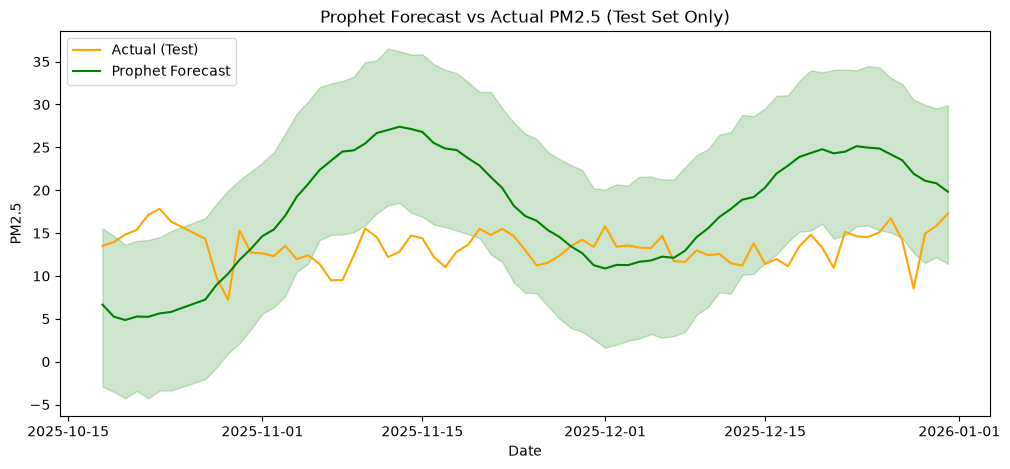

In [55]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(merged.index, merged['y_true'], label='Actual (Test)', color='orange')
plt.plot(merged.index, merged['yhat'], label='Prophet Forecast', color='green')
plt.fill_between(merged.index, merged['yhat_lower'], merged['yhat_upper'],
                 color='green', alpha=0.2)
plt.title('Prophet Forecast vs Actual PM2.5 (Test Set Only)')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

**The plot:** the green forecast line shows how closely Prophet tracks the actual PM2.5 readings over the test period, and the shaded band shows the model's uncertainty around each prediction.

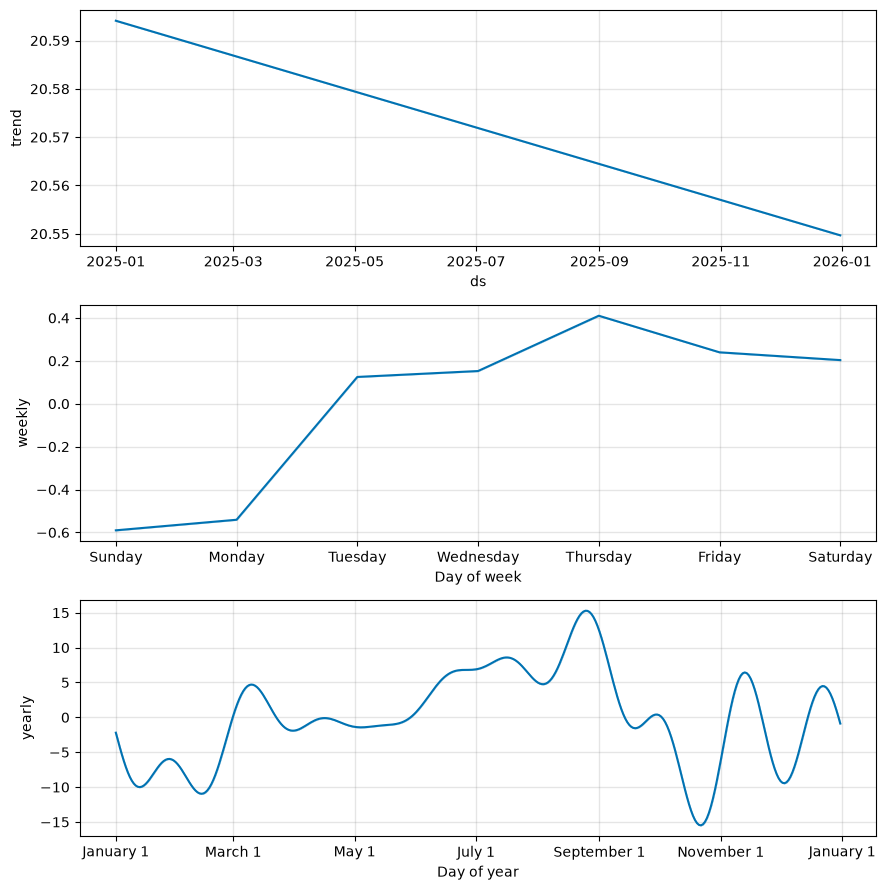

In [56]:
# Prophet component plots
model.plot_components(forecast)
plt.show()

**What drives the forecast:** Prophet breaks the prediction into parts - a long-term trend, a yearly seasonal pattern, and a weekly rhythm. This shows how much of the pollution movement comes from the overall direction versus recurring weekday and seasonal effects.